In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("car_prices.csv")

df.head()

,car_id,mileage,selling_price
0,A001,126958,9734
1,A002,151867,8775
2,A003,136932,3928
3,A004,108694,12454
4,A005,124879,6634


So Let's check the relation between milege and selling price by plotting a scatter plot.

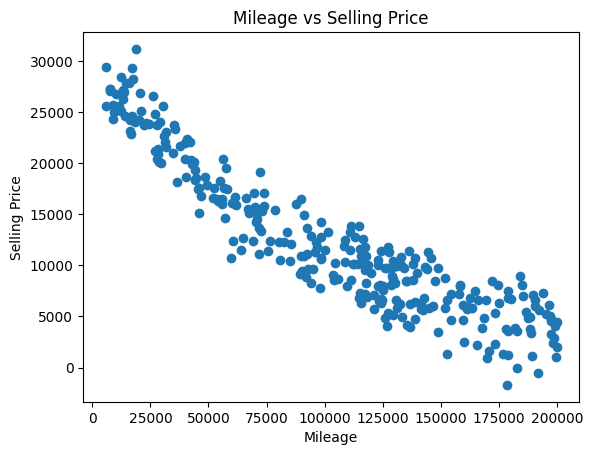

In [16]:
plt.scatter(df["mileage"], df["selling_price"])
plt.title("Mileage vs Selling Price")
plt.xlabel("Mileage")
plt.ylabel("Selling Price")
plt.show()

So as seen in the scatter plot there is ploynomial relation between these two data points.

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# defining Feature and Target Variables
X = df[["mileage"]]
y =df["selling_price"]

# Let's first create a train test split
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=5)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((240, 1), (60, 1), (240,), (60,))

Now the ploynomial equation can have till n number of degrees. How to decide the degree?. Just by trial and error. Here we are taking degree n = 2

Now for finding the degree 2 of mileage we will use inbuilt fns of sklearn which is PolynomialFeatures.Which will allow us to generate those extra columns of mileage for required degree.

In [32]:
from sklearn.preprocessing import PolynomialFeatures

# Create object first for degree = 2
poly = PolynomialFeatures(degree=2)

# Let's just use it first on dummy data 
poly.fit_transform(np.array([[1],[2],[3],[4]]))

array([[ 1.,  1.,  1.],
       [ 1.,  2.,  4.],
       [ 1.,  3.,  9.],
       [ 1.,  4., 16.]])

In [33]:
# Now let's use it on actual data, Which is X_train & X_test
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [34]:
X_train[:5]

,mileage
102,44504
108,43660
96,125151
294,64040
11,131324


In [35]:
X_train_poly[:5]

array([[1.00000000e+00, 4.45040000e+04, 1.98060602e+09],
       [1.00000000e+00, 4.36600000e+04, 1.90619560e+09],
       [1.00000000e+00, 1.25151000e+05, 1.56627728e+10],
       [1.00000000e+00, 6.40400000e+04, 4.10112160e+09],
       [1.00000000e+00, 1.31324000e+05, 1.72459930e+10]])

Now We can use this poly data directly to train our model using LinearRegression.

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
y_pred = model.predict(X_test_poly)
y_pred[:5]

array([23445.60726046, 11259.31281117, 20433.87847387, 10636.26294108,
        4450.96748782])

In [39]:
y_test[:5]

66     23790
239    14270
250    22007
224     9059
24      7097
Name: selling_price, dtype: int64

In [40]:
# Calculate MSE, MAE and r2 Score to check how good the model actually is
MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
R2 = r2_score(y_test, y_pred)

MSE, MAE, R2

(3942449.042820213, 1677.4124341140093, 0.916145076991595)

Now let's check how good the model is without using polynomial Regression.

In [41]:
model = LinearRegression()

# Fitting the simple Data
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
y_not_poly_pred = model.predict(X_test)

In [45]:
y_test[:5]

66     23790
239    14270
250    22007
224     9059
24      7097
Name: selling_price, dtype: int64

In [44]:
y_not_poly_pred[:5]

array([21827.33900485, 13019.47734872, 20004.81327333, 12409.22848967,
        2130.43118071])

In [43]:
# Calculate MSE, MAE and r2 Score of Simple Regression
MSE = mean_squared_error(y_test, y_not_poly_pred)
MAE = mean_absolute_error(y_test, y_not_poly_pred)
R2 = r2_score(y_test, y_not_poly_pred)

MSE, MAE, R2

(7013872.078546727, 2179.8140181195445, 0.8508166632594929)

As we can see here, There is preety good difference between the performance. 